# Assignment 06 — Amazon Stock Price: Dự báo giá bằng RNN

Notebook xây dựng bài toán dự báo **giá đóng cửa (`Close`) của phiên kế tiếp** từ 60 giá gần nhất.
Hai mô hình vanilla RNN tương đương được huấn luyện bằng PyTorch và Keras, đánh giá trên cùng
một phép chia thời gian 80/10/10 và lưu weights để dùng bởi `deploy.py`.


## 1. Thiết lập môi trường và tính tái lập

Seed được cố định cho NumPy, PyTorch và Keras. PyTorch ưu tiên Apple Metal qua
`torch.device("mps")`; nếu MPS không khả dụng, notebook tự chuyển sang CPU và in thiết bị thực tế.


In [1]:
import os
os.environ.setdefault("PYTHONHASHSEED", "42")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/a06-matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/a06-cache")

from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from tensorflow import keras

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"PyTorch {torch.__version__} | device={DEVICE}")
print(f"TensorFlow {tf.__version__} | devices={tf.config.list_physical_devices()}")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)


PyTorch 2.14.0 | device=mps
TensorFlow 2.21.0 | devices=[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 2. Chuỗi thời gian, bài toán supervised và cửa sổ trượt

Chuỗi thời gian có thứ tự: quan sát ở tương lai không được tham gia dự báo quá khứ. Với chuỗi giá
$p_1,p_2,\ldots,p_T$ và độ dài cửa sổ $L=60$, notebook biến dữ liệu thành bài toán supervised:

$$\mathbf{x}^{(i)}=[p_i,p_{i+1},\ldots,p_{i+L-1}],\qquad y^{(i)}=p_{i+L}.$$

`60` tương ứng khoảng ba tháng giao dịch và cân bằng giữa ngữ cảnh với độ dài BPTT. Các cửa sổ có
thể chồng lấn, nhưng target luôn đứng sau toàn bộ input. Split được thực hiện theo target time, không
random split. Validation có nhiệm vụ chọn epoch/hyperparameter; test chỉ được mở một lần để báo cáo.


In [2]:
def sliding_windows(values, lookback):
    """Bien chuoi 1 chieu thanh cac cap (cua so qua khu, gia ke tiep)."""
    values = np.asarray(values, dtype=np.float32)
    X = np.stack([values[i : i + lookback] for i in range(len(values) - lookback)])
    y = values[lookback:]
    return X[..., None], y[:, None]

demo_series = np.array([1.00, 1.05, 1.02, 1.10, 1.12, 1.15], dtype=np.float32)
demo_X, demo_y = sliding_windows(demo_series, lookback=3)
print("X shape:", demo_X.shape, "| y shape:", demo_y.shape)
print("Cua so dau:", demo_X[0, :, 0], "-> muc tieu:", demo_y[0, 0])


X shape: (3, 3, 1) | y shape: (3, 1)
Cua so dau: [1.   1.05 1.02] -> muc tieu: 1.1


## 3. Vanilla RNN và hidden state

RNN xử lý lần lượt từng giá $x_t$. Hidden state $h_t$ đóng vai trò bộ nhớ nén của input hiện tại và
quá khứ:

$$a_t=x_tW_{xh}+h_{t-1}W_{hh}+b_h,\qquad h_t=\tanh(a_t),$$
$$\hat y=W_{hy}h_L+b_y.$$

$W_{xh}$ mã hóa quan sát mới; $W_{hh}$ điều khiển thông tin được giữ/chuyển qua thời gian; tanh giới
hạn hidden state trong $[-1,1]$. Cùng một bộ trọng số được tái sử dụng ở cả 60 bước, nhờ đó số tham
số không tăng theo độ dài chuỗi. Đây là mô hình many-to-one vì chỉ tạo một giá ở cuối cửa sổ.


In [3]:
def numpy_rnn_step(x_t, h_previous, W_xh, W_hh, bias):
    """Mot buoc forward cua vanilla RNN dung tanh."""
    return np.tanh(x_t @ W_xh + h_previous @ W_hh + bias)

rng = np.random.default_rng(RANDOM_STATE)
x_t = np.array([[0.25]], dtype=np.float32)
h_previous = np.zeros((1, 4), dtype=np.float32)
W_xh = rng.normal(0, 0.2, size=(1, 4))
W_hh = rng.normal(0, 0.2, size=(4, 4))
bias = np.zeros((1, 4))
h_t = numpy_rnn_step(x_t, h_previous, W_xh, W_hh, bias)
print("Hidden state h_t:", np.round(h_t, 4))


Hidden state h_t: [[ 0.0152 -0.052   0.0375  0.047 ]]


## 4. Hàm mất mát, tối ưu và BPTT

Bài toán hồi quy tối ưu Mean Squared Error:
$$\mathcal{L}=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat y_i)^2.$$
MSE phạt mạnh sai số lớn và khả vi, phù hợp với Adam. Backpropagation Through Time unroll 60 cell,
tính gradient từ output về hidden state cuối rồi tiếp tục qua từng hidden state trước đó. Adam cập nhật
tham số bằng moment bậc một/hai; scheduler giảm learning rate khi validation loss chững. Khi đánh giá,
MAE dễ đọc theo USD, RMSE nhạy với lỗi lớn, MAPE cho sai số tương đối và $R^2$ đo phần phương sai giải thích.


In [4]:
def mse_loss(y_true, y_pred):
    return np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)

demo_true = np.array([1.10, 1.20, 1.30])
demo_pred = np.array([1.08, 1.24, 1.27])
print(f"MSE minh hoa: {mse_loss(demo_true, demo_pred):.6f}")


MSE minh hoa: 0.000967


## 4.1. Unroll RNN, dạng tensor và chia sẻ tham số

Một RNN có thể được **unroll** thành $L$ bản sao của cùng một cell. Đây không phải $L$ mạng khác nhau:
$W_{xh}$, $W_{hh}$ và bias được chia sẻ ở mọi thời điểm. Với mini-batch, tensor input có dạng
`(batch_size, sequence_length, input_size)`; notebook này có `input_size=1`. Hidden state có dạng
`(num_layers, batch_size, hidden_size)` trong PyTorch. Trạng thái đầu $h_0$ mặc định là vector 0.

Bài toán đang dùng là **many-to-one**: RNN đọc toàn bộ cửa sổ nhưng chỉ hidden state cuối $h_L$
đi qua lớp tuyến tính để tạo một giá dự báo. Many-to-many sẽ cần output tại từng bước, còn
sequence-to-sequence thường có encoder–decoder.

Với input dimension $d$, hidden size $H$ và output size $o$, phần recurrent cần xấp xỉ
$dH+H^2+H$ tham số; lớp output cần $Ho+o$. PyTorch tách recurrent bias thành hai vector nên có
thêm $H$ tham số so với cách viết một bias trong công thức/Keras.


In [5]:
def numpy_rnn_forward(sequence, hidden_size=4, seed=42):
    """Unroll mot vanilla RNN qua toan bo sequence va tra lai moi hidden state."""
    sequence = np.asarray(sequence, dtype=np.float32).reshape(-1, 1)
    generator = np.random.default_rng(seed)
    W_xh = generator.normal(0, 0.25, size=(1, hidden_size))
    W_hh = generator.normal(0, 0.25, size=(hidden_size, hidden_size))
    b_h = np.zeros((1, hidden_size))
    W_hy = generator.normal(0, 0.25, size=(hidden_size, 1))
    b_y = np.zeros((1, 1))
    hidden = np.zeros((1, hidden_size))
    hidden_states = []
    for value in sequence:
        hidden = numpy_rnn_step(value.reshape(1, 1), hidden, W_xh, W_hh, b_h)
        hidden_states.append(hidden.copy())
    prediction = hidden @ W_hy + b_y
    return np.concatenate(hidden_states, axis=0), float(prediction.item())

demo_hidden_states, demo_output = numpy_rnn_forward(demo_series[:4])
print("Hidden states shape:", demo_hidden_states.shape)
print("Many-to-one output:", round(demo_output, 6))
display(pd.DataFrame(demo_hidden_states, columns=[f"h{i + 1}" for i in range(4)]))

input_size, hidden_size, output_size = 1, 64, 1
keras_parameter_count = input_size * hidden_size + hidden_size**2 + hidden_size + hidden_size * output_size + output_size
pytorch_parameter_count = keras_parameter_count + hidden_size
print("So tham so ly thuyet — Keras:", keras_parameter_count)
print("So tham so ly thuyet — PyTorch (hai recurrent bias):", pytorch_parameter_count)


Hidden states shape: (4, 4)
Many-to-one output: 0.095391


,h1,h2,h3,h4
0,0.076032,-0.254292,0.185442,0.230901
1,0.068212,-0.241729,0.212607,0.147634
2,0.062485,-0.208236,0.195137,0.139026
3,0.070117,-0.235745,0.212635,0.167962


So tham so ly thuyet — Keras: 4289
So tham so ly thuyet — PyTorch (hai recurrent bias): 4353


## 4.2. BPTT, vanishing/exploding gradient và các biến thể RNN

Khi BPTT đi qua nhiều bước, gradient chứa tích nhiều Jacobian
$\partial h_t/\partial h_{t-1}$. Nếu chuẩn của tích nhỏ hơn 1, gradient **biến mất** và RNN khó nhớ
quan hệ xa; nếu lớn hơn 1, gradient **bùng nổ**. Hàm tanh còn có đạo hàm
$1-\tanh^2(z)$ rất nhỏ khi activation bão hòa gần $-1$ hoặc $1$.

Notebook giảm rủi ro bằng cửa sổ hữu hạn, chuẩn hóa đầu vào và gradient clipping ở PyTorch.
Dropout 0.2 regularize hidden representation; early stopping chọn epoch theo validation loss.
**LSTM** thêm cell state và các cổng input/forget/output; **GRU** dùng update/reset gate. Hai biến thể
thường giữ phụ thuộc dài tốt hơn, nhưng vanilla RNN được chọn ở đây để thể hiện rõ phương trình cơ bản.


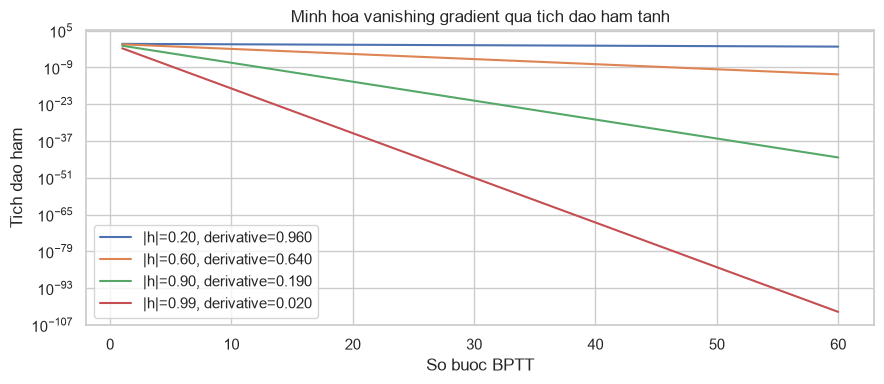

In [6]:
activation_levels = np.array([0.20, 0.60, 0.90, 0.99])
tanh_derivatives = 1.0 - activation_levels**2
steps = np.arange(1, 61)

fig, ax = plt.subplots(figsize=(9, 4))
for activation, derivative in zip(activation_levels, tanh_derivatives):
    ax.plot(steps, derivative**steps, label=f"|h|={activation:.2f}, derivative={derivative:.3f}")
ax.set_yscale("log")
ax.set(title="Minh hoa vanishing gradient qua tich dao ham tanh", xlabel="So buoc BPTT", ylabel="Tich dao ham")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Đọc và mô tả dữ liệu

Dataset có dữ liệu OHLCV theo phiên từ năm 1997 đến 2023. Notebook kiểm tra schema, missing,
duplicate và thứ tự ngày trước khi chỉ lấy `Close` làm tín hiệu đầu vào cho RNN.


In [7]:
def resolve_data_path():
    candidates = [
        Path("../data/AMZN.csv"),
        Path("data/AMZN.csv"),
        Path("src/Assignment 06/Amazon Stock Price/data/AMZN.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Khong tim thay AMZN.csv trong cac duong dan du kien.")

DATA_PATH = resolve_data_path()
DATASET_DIR = DATA_PATH.parent.parent
MODEL_DIR = DATASET_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PYTORCH_WEIGHTS_PATH = MODEL_DIR / "pytorch_rnn.pt"
KERAS_WEIGHTS_PATH = MODEL_DIR / "keras_rnn.weights.h5"
METADATA_PATH = MODEL_DIR / "metadata.json"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
required_columns = {"Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Thieu cot bat buoc: {sorted(missing_columns)}")
if df["Date"].duplicated().any():
    raise ValueError("Date bi trung; can xu ly truoc khi tao chuoi.")
if not df["Date"].is_monotonic_increasing:
    raise ValueError("Date chua tang dan.")

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
print(f"Data path: {DATA_PATH}")
print(f"Shape: {df.shape} | Date: {df['Date'].min().date()} -> {df['Date'].max().date()}")
display(audit)
display(df.describe(include="all").T)
display(df.head())


Data path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Amazon Stock Price/data/AMZN.csv
Shape: (6684, 7) | Date: 1997-05-15 -> 2023-12-05


,dtype,missing,unique
Date,datetime64[us],0,6684
Open,float64,0,5952
High,float64,0,5910
Low,float64,0,5915
Close,float64,0,6052
Adj Close,float64,0,6052
Volume,int64,0,6491


,count,mean,min,25%,50%,75%,max,std
Date,6684,2010-08-25 19:12:36.193895,1997-05-15 00:00:00,2004-01-06 18:00:00,2010-08-25 12:00:00,2017-04-17 06:00:00,2023-12-05 00:00:00,NaN
Open,6684.0,34.029317,0.070313,2.036875,7.1235,45.203874,187.199997,49.856923
High,6684.0,34.439204,0.072396,2.07475,7.178,45.475624,188.654007,50.442953
Low,6684.0,33.584667,0.065625,1.994625,6.98675,44.870125,184.839493,49.213548
Close,6684.0,34.020316,0.069792,2.0425,7.10475,45.13575,186.570496,49.829566
Adj Close,6684.0,34.020316,0.069792,2.0425,7.10475,45.13575,186.570496,49.829566
Volume,6684.0,140378574.401556,9744000.0,67169500.0,103979000.0,158781000.0,2086584000.0,139074657.090682


,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


## 6. EDA và phân bố dữ liệu

Biểu đồ thể hiện toàn bộ lịch sử `Close`, phân phối giá, phân phối phần trăm thay đổi theo ngày
và volume theo thời gian. Trục volume dùng log để các giai đoạn có quy mô khác nhau vẫn dễ quan sát.


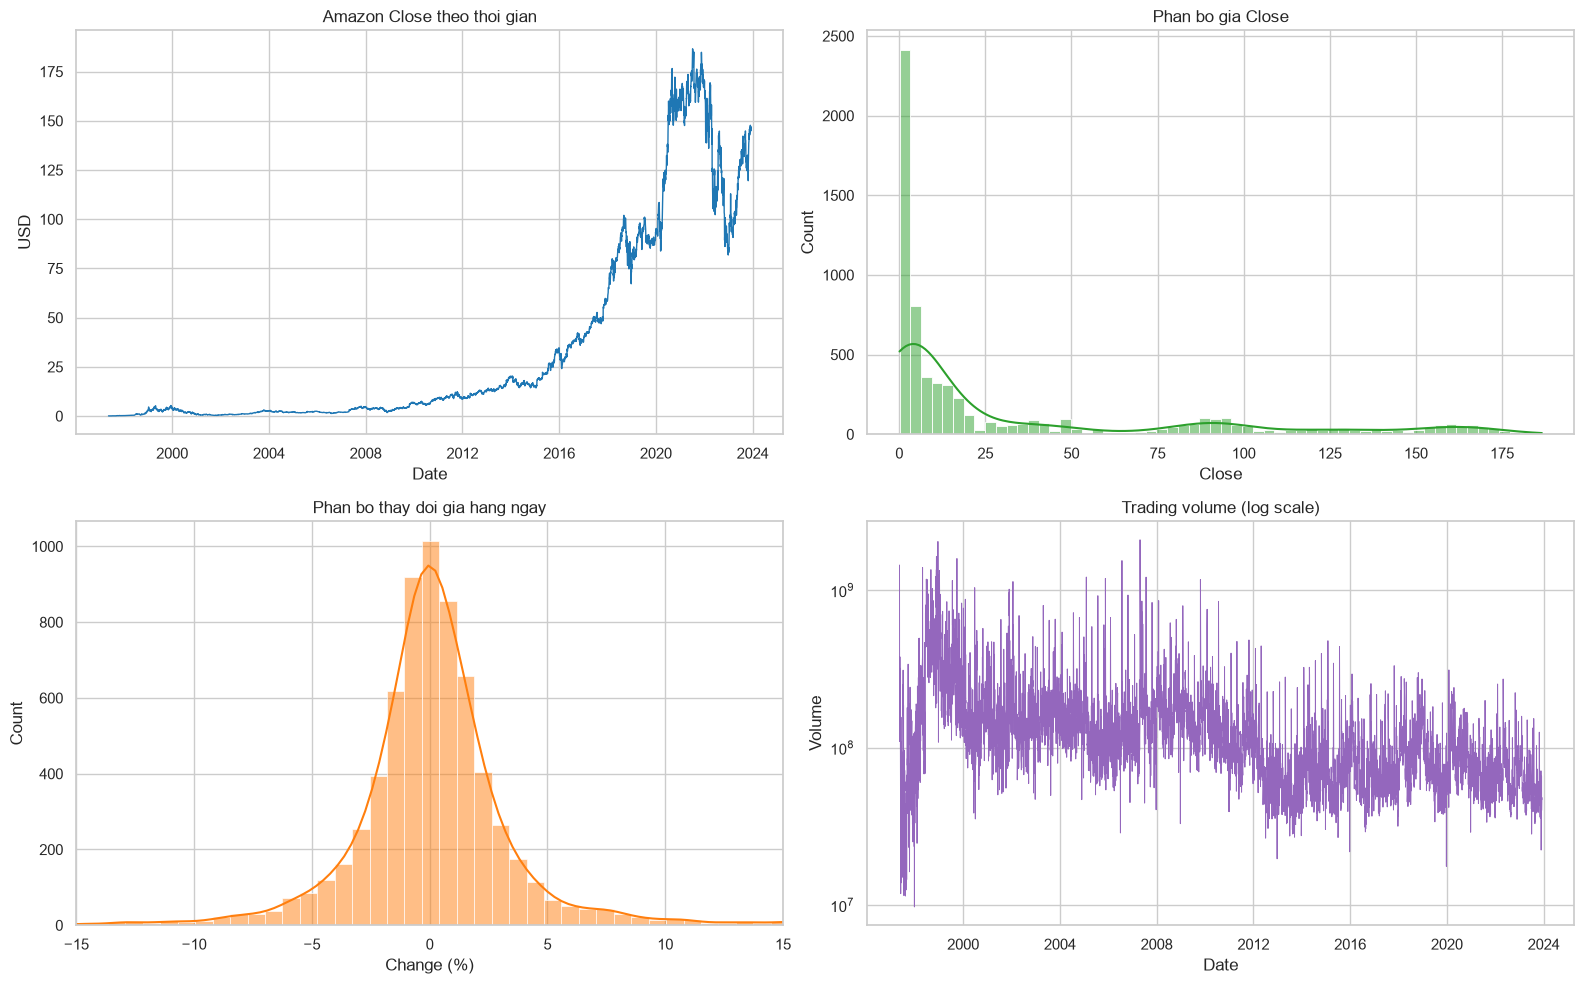

,Close_mean,Close_std
Date,,
2014-12-31,16.627552,1.383261
2015-12-31,23.906915,5.537250
2016-12-31,34.976157,4.618116
2017-12-31,48.408351,5.329010
2018-12-31,82.086309,9.863754
2019-12-31,89.459460,5.065682
2020-12-31,134.042755,27.288052
2021-12-31,167.193349,8.002098
2022-12-31,126.098819,23.904315


In [8]:
df["Close_change_pct"] = df["Close"].pct_change() * 100
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(df["Date"], df["Close"], color="tab:blue", linewidth=1)
axes[0, 0].set(title="Amazon Close theo thoi gian", xlabel="Date", ylabel="USD")
sns.histplot(df["Close"], bins=60, kde=True, ax=axes[0, 1], color="tab:green")
axes[0, 1].set(title="Phan bo gia Close", xlabel="Close")
sns.histplot(df["Close_change_pct"].dropna(), bins=80, kde=True, ax=axes[1, 0], color="tab:orange")
axes[1, 0].set(title="Phan bo thay doi gia hang ngay", xlabel="Change (%)", xlim=(-15, 15))
axes[1, 1].plot(df["Date"], df["Volume"], color="tab:purple", linewidth=0.7)
axes[1, 1].set_yscale("log")
axes[1, 1].set(title="Trading volume (log scale)", xlabel="Date", ylabel="Volume")
plt.tight_layout()
plt.show()

yearly = df.set_index("Date").resample("YE").agg(Close_mean=("Close", "mean"), Close_std=("Close", "std"))
display(yearly.tail(10))


## 6.1. Phân tích thống kê, tính phụ thuộc thời gian và ngoại lệ

Ngoài histogram, cần kiểm tra phân phối lệch, quantile, volatility và autocorrelation. Giá tuyệt đối
thường không dừng vì xu hướng dài hạn; phần trăm thay đổi gần dừng hơn. Rolling mean/std cho thấy
regime thị trường thay đổi theo thời gian. Correlation OHLC cao là tự nhiên vì chúng cùng thuộc một phiên;
correlation không đồng nghĩa quan hệ nhân quả. Các phiên biến động cực đoan được liệt kê để tránh nhầm
chúng với missing/error dữ liệu.


Close quantiles:


,Close
0.01,0.116883
0.05,0.487525
0.25,2.042500
0.50,7.104750
0.75,45.135750
0.95,156.938124
0.99,172.348905


Daily-return statistics:


,daily return
mean (%),0.172280
std/volatility (%),3.577751
skewness,1.048747
excess kurtosis,10.962773
min (%),-24.766064
max (%),34.471366


Autocorrelation:


,Close autocorrelation
lag_1,0.999662
lag_5,0.998388
lag_20,0.993980
lag_60,0.983738


10 phien co bien dong tuyet doi lon nhat:


,Date,Close,Close_change_pct,Volume
1056,2001-07-24,0.603000,-24.766064,651458000
1177,2002-01-22,0.630000,24.015748,1132918000
2563,2007-07-25,4.309000,24.447653,1209048000
958,2001-03-05,0.631250,26.250000,470014000
917,2001-01-03,0.878125,26.576577,293608000
3131,2009-10-23,5.924500,26.795078,1166116000
2500,2007-04-25,2.840500,26.949721,2086584000
1132,2001-11-14,0.474500,30.178326,590596000
983,2001-04-09,0.559000,33.572282,468114000
1139,2001-11-26,0.610500,34.471366,1013784000


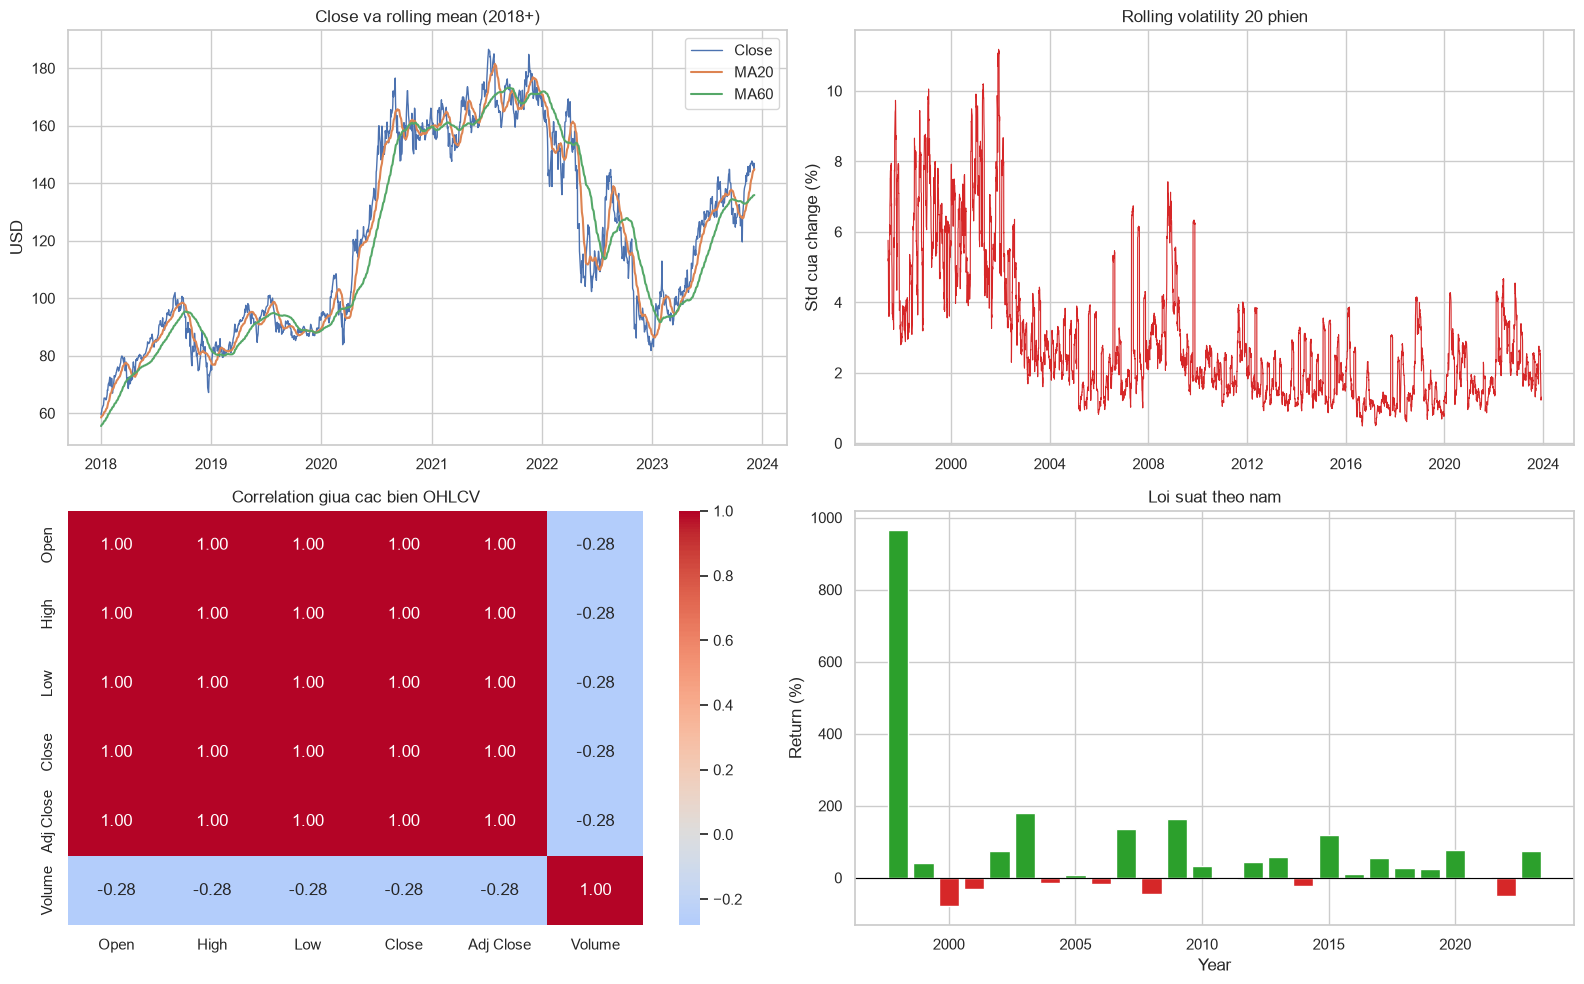

In [9]:
price_quantiles = df["Close"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).rename("Close")
return_series = df["Close_change_pct"].dropna()
return_summary = pd.Series({
    "mean (%)": return_series.mean(),
    "std/volatility (%)": return_series.std(),
    "skewness": return_series.skew(),
    "excess kurtosis": return_series.kurt(),
    "min (%)": return_series.min(),
    "max (%)": return_series.max(),
}, name="daily return")
autocorrelation = pd.Series(
    {f"lag_{lag}": df["Close"].autocorr(lag=lag) for lag in [1, 5, 20, 60]},
    name="Close autocorrelation",
)
print("Close quantiles:")
display(price_quantiles.to_frame())
print("Daily-return statistics:")
display(return_summary.to_frame())
print("Autocorrelation:")
display(autocorrelation.to_frame())

df["Close_MA20"] = df["Close"].rolling(20).mean()
df["Close_MA60"] = df["Close"].rolling(60).mean()
df["Return_STD20"] = df["Close_change_pct"].rolling(20).std()
extreme_moves = df.loc[
    df["Close_change_pct"].abs().nlargest(10).index,
    ["Date", "Close", "Close_change_pct", "Volume"],
].sort_values("Close_change_pct")
print("10 phien co bien dong tuyet doi lon nhat:")
display(extreme_moves)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
recent = df[df["Date"] >= "2018-01-01"]
axes[0, 0].plot(recent["Date"], recent["Close"], label="Close", linewidth=1)
axes[0, 0].plot(recent["Date"], recent["Close_MA20"], label="MA20")
axes[0, 0].plot(recent["Date"], recent["Close_MA60"], label="MA60")
axes[0, 0].set(title="Close va rolling mean (2018+)", ylabel="USD")
axes[0, 0].legend()
axes[0, 1].plot(df["Date"], df["Return_STD20"], color="tab:red", linewidth=0.8)
axes[0, 1].set(title="Rolling volatility 20 phien", ylabel="Std cua change (%)")
correlation = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1, 0])
axes[1, 0].set(title="Correlation giua cac bien OHLCV")
annual_return = df.set_index("Date")["Close"].resample("YE").last().pct_change() * 100
axes[1, 1].bar(annual_return.index.year, annual_return.values, color=np.where(annual_return >= 0, "tab:green", "tab:red"))
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set(title="Loi suat theo nam", xlabel="Year", ylabel="Return (%)")
plt.tight_layout()
plt.show()


## 7. Tạo sequence và split thời gian 80/10/10

Split được thực hiện trên các mẫu cửa sổ theo thứ tự thời gian, tuyệt đối không shuffle giữa các tập.
`StandardScaler` chỉ fit trên prefix dữ liệu kết thúc ở target cuối của train; validation/test không
tham gia ước lượng mean hay standard deviation.


In [10]:
LOOKBACK = 60
raw_prices = df["Close"].to_numpy(dtype=np.float32)
target_dates = df["Date"].iloc[LOOKBACK:].reset_index(drop=True)
n_samples = len(raw_prices) - LOOKBACK
n_train = int(n_samples * 0.80)
n_val = int(n_samples * 0.10)
n_test = n_samples - n_train - n_val
train_target_end = LOOKBACK + n_train

scaler = StandardScaler()
scaler.fit(raw_prices[:train_target_end].reshape(-1, 1))
scaled_prices = scaler.transform(raw_prices.reshape(-1, 1)).reshape(-1).astype(np.float32)
X_all, y_all = sliding_windows(scaled_prices, LOOKBACK)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val, y_val = X_all[n_train : n_train + n_val], y_all[n_train : n_train + n_val]
X_test, y_test = X_all[n_train + n_val :], y_all[n_train + n_val :]
y_test_raw = raw_prices[LOOKBACK + n_train + n_val :]
baseline_test = raw_prices[LOOKBACK + n_train + n_val - 1 : -1]
test_dates = target_dates.iloc[n_train + n_val :].reset_index(drop=True)

assert len(X_train) + len(X_val) + len(X_test) == n_samples
assert np.isfinite(X_all).all() and np.isfinite(y_all).all()
split_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "samples": [len(X_train), len(X_val), len(X_test)],
    "ratio (%)": np.array([len(X_train), len(X_val), len(X_test)]) / n_samples * 100,
})
display(split_table)
print(f"Scaler train-only: mean={scaler.mean_[0]:.6f}, scale={scaler.scale_[0]:.6f}")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


,split,samples,ratio (%)
0,train,5299,79.996981
1,validation,662,9.993961
2,test,663,10.009058


Scaler train-only: mean=11.580532, scale=17.444716
Shapes: (5299, 60, 1) (662, 60, 1) (663, 60, 1)


## 8. Kiến trúc, hyperparameter và hàm dùng chung

Hai framework cùng dùng `SimpleRNN/nn.RNN(1 → 64, tanh) → Dropout(0.2) → Linear(1)`, Adam
`learning_rate=1e-3`, MSE và batch size 64. Ngân sách được tăng lên **tối đa 250 epoch**, huấn luyện
ít nhất 30 epoch và early stopping patience 25. `ReduceLROnPlateau` giảm learning rate một nửa sau
5 epoch validation không cải thiện. Cấu hình chung giúp phép so sánh tập trung vào framework.


In [11]:
MODEL_CONFIG = {
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.2,
}
MAX_EPOCHS = 250
MIN_EPOCHS = 30
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 25


class TorchPriceRNN(nn.Module):
    def __init__(self, config=MODEL_CONFIG):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=config["input_size"],
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            nonlinearity="tanh",
            batch_first=True,
        )
        self.dropout = nn.Dropout(config["dropout"])
        self.output = nn.Linear(config["hidden_size"], 1)

    def forward(self, inputs):
        sequence_output, _ = self.rnn(inputs)
        return self.output(self.dropout(sequence_output[:, -1, :]))


def build_keras_rnn(model_name="price_rnn"):
    inputs = keras.Input(shape=(LOOKBACK, MODEL_CONFIG["input_size"]), name="price_sequence")
    hidden = keras.layers.SimpleRNN(
        MODEL_CONFIG["hidden_size"], activation="tanh", name="simple_rnn"
    )(inputs)
    hidden = keras.layers.Dropout(MODEL_CONFIG["dropout"], name="dropout")(hidden)
    outputs = keras.layers.Dense(1, name="price_output")(hidden)
    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE), loss="mse")
    return model


def make_loader(X, y, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).float())
    generator = torch.Generator().manual_seed(RANDOM_STATE)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
    )


def run_torch_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    criterion = nn.MSELoss()
    for batch_X, batch_y in loader:
        batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
        if training:
            optimizer.zero_grad(set_to_none=True)
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        total_loss += loss.item() * len(batch_X)
    return total_loss / len(loader.dataset)


def predict_torch(model, X):
    model.eval()
    predictions = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=BATCH_SIZE)
    with torch.no_grad():
        for (batch_X,) in loader:
            predictions.append(model(batch_X.to(DEVICE)).cpu().numpy())
    return np.concatenate(predictions).reshape(-1)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100,
        "R2": r2_score(y_true, y_pred),
    }


## 9. Huấn luyện RNN bằng PyTorch

Mini-batch train được shuffle nhưng các phần train/validation/test không bị trộn. Best state theo
validation loss được lưu thành `models/pytorch_rnn.pt` và được phục hồi trước khi dự đoán test.


In [12]:
train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)

torch_model = TorchPriceRNN().to(DEVICE)
optimizer = torch.optim.Adam(torch_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0
torch_history = {"loss": [], "val_loss": [], "learning_rate": []}

torch_start = time.perf_counter()
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_torch_epoch(torch_model, train_loader, optimizer)
    val_loss = run_torch_epoch(torch_model, val_loader)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    torch_history["loss"].append(train_loss)
    torch_history["val_loss"].append(val_loss)
    torch_history["learning_rate"].append(current_lr)

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = copy.deepcopy(torch_model.state_dict())
        epochs_without_improvement = 0
        torch.save(
            {"state_dict": best_state, "model_config": MODEL_CONFIG},
            PYTORCH_WEIGHTS_PATH,
        )
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | train={train_loss:.6f} | "
            f"val={val_loss:.6f} | lr={current_lr:.2e}"
        )
    if epoch >= MIN_EPOCHS and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping tai epoch {epoch}.")
        break

torch_train_seconds = time.perf_counter() - torch_start
torch_model.load_state_dict(best_state)
torch_scaled_prediction = predict_torch(torch_model, X_test)
print(f"PyTorch hoan tat trong {torch_train_seconds:.2f}s; best val loss={best_val_loss:.6f}")


Epoch 001 | train=0.178609 | val=5.266870 | lr=1.00e-03


Epoch 010 | train=0.005766 | val=1.987922 | lr=1.00e-03


Epoch 020 | train=0.006129 | val=1.137135 | lr=1.00e-03


Epoch 030 | train=0.005416 | val=0.899365 | lr=1.00e-03


Epoch 040 | train=0.004985 | val=0.696580 | lr=1.00e-03


...

Epoch 070 | train=0.004700 | val=0.311509 | lr=5.00e-04


Epoch 080 | train=0.004698 | val=0.398837 | lr=2.50e-04


Epoch 090 | train=0.004271 | val=0.384622 | lr=1.25e-04


Epoch 100 | train=0.004517 | val=0.367282 | lr=3.13e-05


Early stopping tai epoch 107.
PyTorch hoan tat trong 101.50s; best val loss=0.309872


## 10. Huấn luyện RNN bằng Keras

`ModelCheckpoint` lưu weights có validation loss tốt nhất. `EarlyStopping` và
`ReduceLROnPlateau` dùng cùng patience/chính sách với phần PyTorch.


In [13]:
MODEL_NAME = "amazon_price_rnn"

keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_STATE)
keras_model = build_keras_rnn(MODEL_NAME)
keras_callbacks = [
    keras.callbacks.ModelCheckpoint(
        KERAS_WEIGHTS_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=0,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        start_from_epoch=MIN_EPOCHS,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

keras_start = time.perf_counter()
keras_fit = keras_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=keras_callbacks,
    verbose=2,
)
keras_train_seconds = time.perf_counter() - keras_start
keras_model.load_weights(KERAS_WEIGHTS_PATH)
keras_scaled_prediction = keras_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).reshape(-1)
keras_history = keras_fit.history
print(
    f"Keras hoan tat trong {keras_train_seconds:.2f}s; "
    f"best val loss={min(keras_history['val_loss']):.6f}"
)


Epoch 1/250


83/83 - 1s - 11ms/step - loss: 0.0784 - val_loss: 5.7702 - learning_rate: 0.0010


Epoch 2/250


83/83 - 0s - 3ms/step - loss: 0.0163 - val_loss: 4.6175 - learning_rate: 0.0010


Epoch 3/250


...


Epoch 75: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


83/83 - 0s - 3ms/step - loss: 0.0040 - val_loss: 0.4739 - learning_rate: 3.1250e-05


Epoch 75: early stopping


Restoring model weights from the end of the best epoch: 50.


Keras hoan tat trong 18.88s; best val loss=0.326779


## 11. Đánh giá trên test set

Mọi dự đoán được inverse-transform về USD trước khi tính MAE, RMSE, MAPE và $R^2$.
Baseline persistence dự báo giá tiếp theo bằng giá cuối của cửa sổ.


,MAE,RMSE,MAPE (%),R2,Train time (s)
Model,,,,,
Persistence baseline,2.2720,3.1507,1.7519,0.9874,0.0000
PyTorch RNN,10.4466,13.6738,6.7825,0.7633,101.4997
Keras RNN,10.5704,14.1749,6.8377,0.7456,18.8772


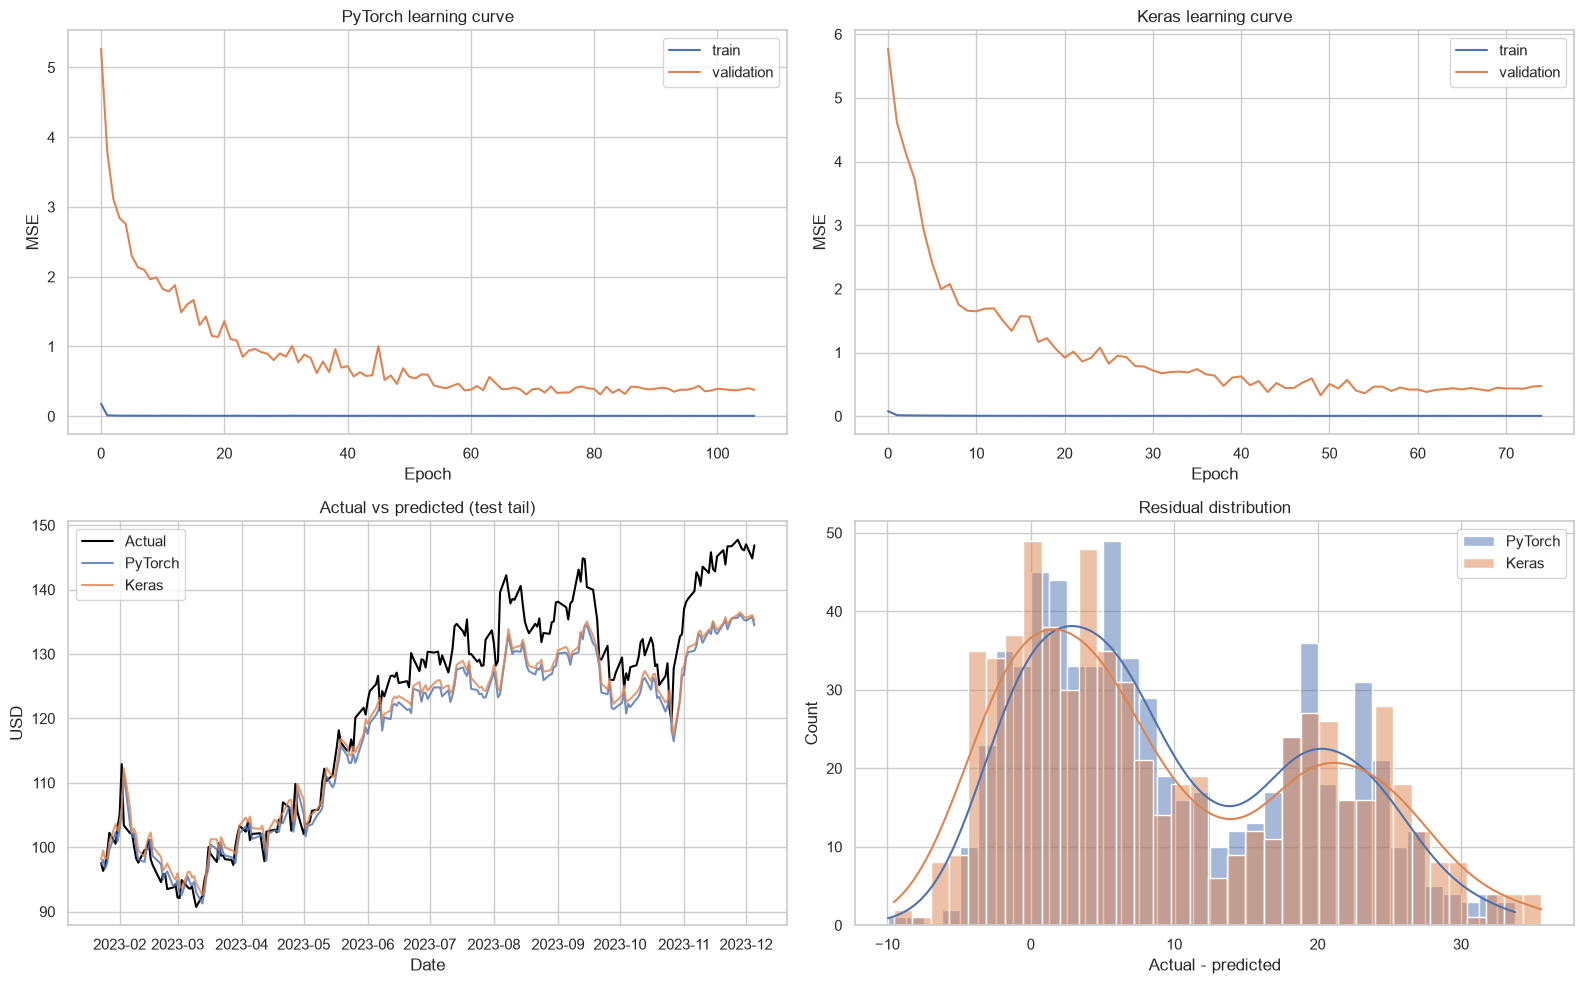

In [14]:
def inverse_amazon(values):
    values = np.asarray(values).reshape(-1, 1)
    return scaler.inverse_transform(values).reshape(-1)

torch_prediction = inverse_amazon(torch_scaled_prediction)
keras_prediction = inverse_amazon(keras_scaled_prediction)
predictions = {
    "Persistence baseline": baseline_test,
    "PyTorch RNN": torch_prediction,
    "Keras RNN": keras_prediction,
}
results = []
for name, prediction in predictions.items():
    row = {"Model": name, **regression_metrics(y_test_raw, prediction)}
    if name == "PyTorch RNN":
        row["Train time (s)"] = torch_train_seconds
    elif name == "Keras RNN":
        row["Train time (s)"] = keras_train_seconds
    else:
        row["Train time (s)"] = 0.0
    results.append(row)
results_df = pd.DataFrame(results).set_index("Model").sort_values("RMSE")
display(results_df.style.format({column: "{:.4f}" for column in results_df.columns}))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(torch_history["loss"], label="train")
axes[0, 0].plot(torch_history["val_loss"], label="validation")
axes[0, 0].set(title="PyTorch learning curve", xlabel="Epoch", ylabel="MSE")
axes[0, 0].legend()
axes[0, 1].plot(keras_history["loss"], label="train")
axes[0, 1].plot(keras_history["val_loss"], label="validation")
axes[0, 1].set(title="Keras learning curve", xlabel="Epoch", ylabel="MSE")
axes[0, 1].legend()
plot_tail = min(220, len(y_test_raw))
axes[1, 0].plot(test_dates.iloc[-plot_tail:], y_test_raw[-plot_tail:], label="Actual", color="black")
axes[1, 0].plot(test_dates.iloc[-plot_tail:], torch_prediction[-plot_tail:], label="PyTorch", alpha=0.8)
axes[1, 0].plot(test_dates.iloc[-plot_tail:], keras_prediction[-plot_tail:], label="Keras", alpha=0.8)
axes[1, 0].set(title="Actual vs predicted (test tail)", xlabel="Date", ylabel="USD")
axes[1, 0].legend()
sns.histplot(y_test_raw - torch_prediction, bins=35, kde=True, ax=axes[1, 1], label="PyTorch", alpha=0.5)
sns.histplot(y_test_raw - keras_prediction, bins=35, kde=True, ax=axes[1, 1], label="Keras", alpha=0.5)
axes[1, 1].set(title="Residual distribution", xlabel="Actual - predicted")
axes[1, 1].legend()
plt.tight_layout()
plt.show()


## 12. Lưu metadata và kiểm chứng khả năng deploy

Metadata chứa lookback, scaler train-only, kiến trúc và tên artifacts. Cell dựng hai model mới,
nạp weights từ ổ đĩa và kiểm tra dự đoán trùng với model vừa huấn luyện.


In [15]:
metadata = {
    "dataset": "Amazon Stock Price",
    "target": "Close",
    "lookback": LOOKBACK,
    "split": {"train": len(X_train), "validation": len(X_val), "test": len(X_test)},
    "scaler": {"mean": float(scaler.mean_[0]), "scale": float(scaler.scale_[0])},
    "model_config": MODEL_CONFIG,
    "training_config": {
        "max_epochs": MAX_EPOCHS,
        "min_epochs": MIN_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    },
    "artifacts": {"pytorch": PYTORCH_WEIGHTS_PATH.name, "keras": KERAS_WEIGHTS_PATH.name},
    "training_device": str(DEVICE),
    "framework_versions": {"torch": torch.__version__, "tensorflow": tf.__version__},
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

reloaded_torch = TorchPriceRNN().to(DEVICE)
try:
    checkpoint = torch.load(PYTORCH_WEIGHTS_PATH, map_location=DEVICE, weights_only=True)
except TypeError:
    checkpoint = torch.load(PYTORCH_WEIGHTS_PATH, map_location=DEVICE)
reloaded_torch.load_state_dict(checkpoint["state_dict"])
reloaded_torch_value = predict_torch(reloaded_torch, X_test[:1])[0]

reloaded_keras = build_keras_rnn(MODEL_NAME)
reloaded_keras.load_weights(KERAS_WEIGHTS_PATH)
reloaded_keras_value = reloaded_keras.predict(X_test[:1], verbose=0).reshape(-1)[0]
assert np.allclose(reloaded_torch_value, torch_scaled_prediction[0], atol=1e-6)
assert np.allclose(reloaded_keras_value, keras_scaled_prediction[0], atol=1e-6)
assert PYTORCH_WEIGHTS_PATH.exists() and KERAS_WEIGHTS_PATH.exists() and METADATA_PATH.exists()
print("Reload verification: PASS")
print("Artifacts:", PYTORCH_WEIGHTS_PATH, KERAS_WEIGHTS_PATH, METADATA_PATH, sep="\n- ")


Reload verification: PASS
Artifacts:
- /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Amazon Stock Price/models/pytorch_rnn.pt
- /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Amazon Stock Price/models/keras_rnn.weights.h5
- /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 06/Amazon Stock Price/models/metadata.json


/opt/miniconda3/envs/ISD/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(store)


## 13. Kết luận

Bảng test cho biết RNN có cải thiện so với baseline persistence hay không. Với giá cổ phiếu,
baseline thường rất mạnh vì chuỗi có tính liên tục cao; vì vậy không nên kết luận chỉ từ loss chuẩn hóa.
Weights tốt nhất của cả hai framework cùng scaler train-only đã sẵn sàng cho `deploy.py`.
